In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
os.chdir("/content/drive/MyDrive/Testing_data 09 11 2025")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
imu = pd.read_csv("/content/drive/MyDrive/Testing_data 09 11 2025/2025-11-09/IMU and GPS complete/imu_data_log_2025-11-09.csv")

/tmp/ipython-input-2850364571.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  imu = pd.read_csv("/content/drive/MyDrive/Testing_data 09 11 2025/2025-11-09/IMU and GPS complete/imu_data_log_2025-11-09.csv")


In [ ]:
imu.head()

,Timestamp (s),xacc (mg),yacc (mg),zacc (mg),xgyro (mrad/s),ygyro (mrad/s),zgyro (mrad/s),yaw,roll,pitch
0,1.762658e+09,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.762658e+09,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.762658e+09,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.762658e+09,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.762658e+09,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Column names (from your previous screenshot)
COL_TIME = 'Timestamp (s)'
COL_AX = 'xacc (mg)'
COL_AY = 'yacc (mg)'
COL_AZ = 'zacc (mg)'

# Calibration Range (Indices)
CAL_START = 15
CAL_END = 1200

In [ ]:
def calibrate_imu_user_logic(imu):
    print("--- Loading IMU Data ---")
    df = imu

    # Ensure numerics
    cols = [COL_AX, COL_AY, COL_AZ]
    for c in cols:
        df[c] = pd.to_numeric(df[c], errors='coerce')

    # 1. Slice the Static Region (Rows 15 to 2000)
    # Note: Python is 0-indexed, so we use iloc logic carefully.
    df_static = df.iloc[CAL_START:CAL_END].copy()

    print(f"Using {len(df_static)} points for calibration (Row {CAL_START} to {CAL_END})")

    # 2. Find Resultant 'G' for each static point, then average
    # G = sqrt(x^2 + y^2 + z^2)
    df_static['G_mag'] = np.sqrt(
        df_static[COL_AX]**2 +
        df_static[COL_AY]**2 +
        df_static[COL_AZ]**2
    )

    # This is the "G" value your sensor sees as 1g
    G_avg = df_static['G_mag'].mean()
    print(f"Calculated Sensor 'G' Magnitude: {G_avg:.4f} mg")

    # 3. Calculate Cos Alpha (for X) and Cos Beta (for Y)
    # cos_alpha = x_value / G
    # We take the average of these ratios to get a stable constant
    avg_cos_alpha = (df_static[COL_AX] / df_static['G_mag']).mean()
    avg_cos_beta  = (df_static[COL_AY] / df_static['G_mag']).mean()

    # Calculate Sin Alpha / Sin Beta (needed for the division)
    # sin^2 + cos^2 = 1  =>  sin = sqrt(1 - cos^2)
    sin_alpha = np.sqrt(1 - avg_cos_alpha**2)
    sin_beta  = np.sqrt(1 - avg_cos_beta**2)

    print(f"\n--- Calibration Constants ---")
    print(f"X-Axis: cos(alpha) = {avg_cos_alpha:.6f} | sin(alpha) = {sin_alpha:.6f}")
    print(f"Y-Axis: cos(beta)  = {avg_cos_beta:.6f} | sin(beta)  = {sin_beta:.6f}")

    # Sanity Check: If sensor is flat, cos_alpha should be near 0, sin_alpha near 1.
    angle_x_deg = np.degrees(np.arccos(avg_cos_alpha))
    print(f"Implied Angle of X to Gravity: {angle_x_deg:.2f} degrees (90 is flat)")

    # 4. Apply Correction to Entire Dataset
    # Formula: arx = (ax - G * cos_alpha) / sin_alpha

    # We use the constants calculated above
    bias_x = G_avg * avg_cos_alpha
    bias_y = G_avg * avg_cos_beta

    df['arx_mg'] = (df[COL_AX] - bias_x) / sin_alpha
    df['ary_mg'] = (df[COL_AY] - bias_y) / sin_beta

    # 5. Convert to m/s^2 for final physics usage
    # Assuming standard gravity 9.80665 m/s^2 corresponds to the sensor's "G_avg"
    # Or strict conversion: 1 mg = 0.00980665 m/s^2
    # Let's use strict unit conversion:
    GRAVITY_CONST = 9.80665
    df['arx_mps2'] = -1*df['arx_mg'] * (GRAVITY_CONST / 1000.0)# Because a forward accel will give a negative value in ax
    df['ary_mps2'] = -1*df['ary_mg'] * (GRAVITY_CONST / 1000.0)#similarly for ay
    df['bias_corrected_arx_mps2']= df['arx_mps2'] - df['arx_mps2'].iloc[15:1200].mean()
    df['bias_corrected_ary_mps2']= df['ary_mps2'] - df['ary_mps2'].iloc[15:1200].mean()
    # Save Output
    output_file = '/content/drive/MyDrive/Testing_data 09 11 2025/imu_calibrated_user_logic.csv'
    df.to_csv(output_file, index=False)
    print(f"\nProcessing complete. Saved to: {output_file}")

    # --- Plotting to Verify ---
    plt.figure(figsize=(10, 6))

    plt.subplot(2, 1, 1)
    plt.plot(df.index, df[COL_AX], label='Raw X (mg)', alpha=0.5)
    plt.plot(df.index, df['arx_mg'], label='Corrected X (mg)', color='red')
    plt.title("X-Axis Calibration")
    plt.legend()
    plt.grid(True)

    plt.subplot(2, 1, 2)
    plt.plot(df.index[CAL_START:CAL_END], df['arx_mg'].iloc[CAL_START:CAL_END], color='green')
    plt.title("Check: Corrected X during Static Period (Should be centered at 0)")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    return df



--- Loading IMU Data ---
Using 1185 points for calibration (Row 15 to 1200)
Calculated Sensor 'G' Magnitude: 999.9899 mg

--- Calibration Constants ---
X-Axis: cos(alpha) = -0.031010 | sin(alpha) = 0.999519
Y-Axis: cos(beta)  = -0.088551 | sin(beta)  = 0.996072
Implied Angle of X to Gravity: 91.78 degrees (90 is flat)

Processing complete. Saved to: /content/drive/MyDrive/Testing_data 09 11 2025/imu_calibrated_user_logic.csv


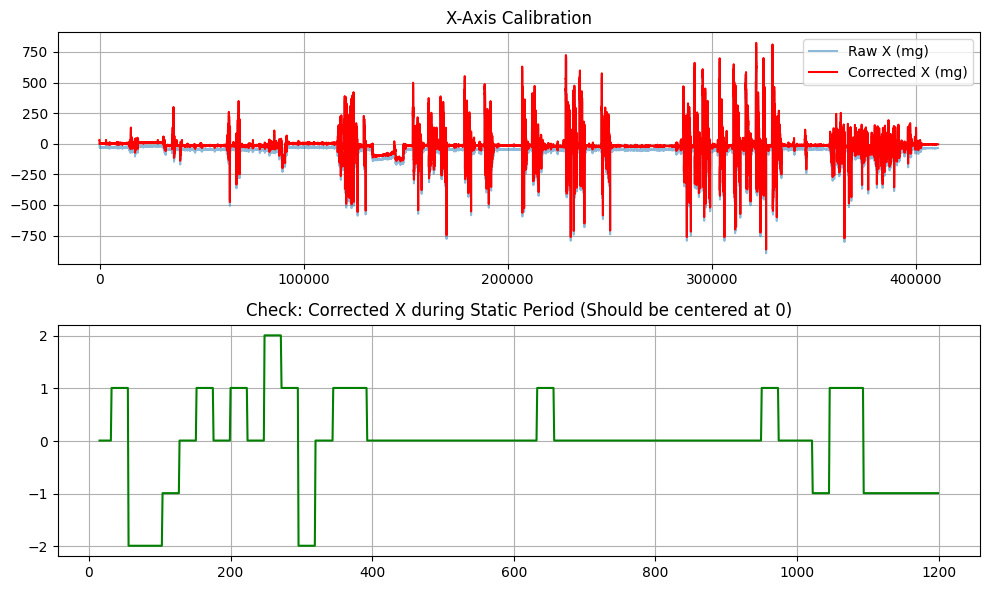

In [ ]:
imu_corrected_df=calibrate_imu_user_logic(imu)#Running the calibration

In [ ]:
imu_corrected_df.iloc[15:500].mean()

,0
Timestamp (s),1.762658e+09
xacc (mg),-3.095052e+01
yacc (mg),-8.937938e+01
zacc (mg),-9.893505e+02
xgyro (mrad/s),-4.162887e+00
ygyro (mrad/s),1.048866e+01
zgyro (mrad/s),-9.525773e-01
yaw,1.877820e+00
roll,8.550977e-02
pitch,-2.135099e-02


In [ ]:
imu_corrected_df.head()

,Timestamp (s),xacc (mg),yacc (mg),zacc (mg),xgyro (mrad/s),ygyro (mrad/s),zgyro (mrad/s),yaw,roll,pitch,arx_mg,ary_mg,arx_mps2,ary_mps2,bias_corrected_arx_mps2,bias_corrected_ary_mps2
0,1.762658e+09,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,31.024515,88.899035,-0.304247,-0.871802,-0.304235,-0.871731
1,1.762658e+09,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,31.024515,88.899035,-0.304247,-0.871802,-0.304235,-0.871731
2,1.762658e+09,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,31.024515,88.899035,-0.304247,-0.871802,-0.304235,-0.871731
3,1.762658e+09,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,31.024515,88.899035,-0.304247,-0.871802,-0.304235,-0.871731
4,1.762658e+09,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,31.024515,88.899035,-0.304247,-0.871802,-0.304235,-0.871731
